In [32]:
import numpy as np
import matplotlib.pyplot as plt
from optic.models.tx import pamTransmitter
from optic.models.devices import photodiode, edfa, dac, adc, mzm, basicLaserModel
from optic.dsp.equalization import dfe, ffe
from optic.models.channels import linearFiberChannel, awgn
from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping , demodulateGray
from optic.comm.metrics import bert, fastBERcalc, theoryBER
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate ,signalPower
from optic.utils import parameters, dBm2W 
from optic.plot import eyediagram
from scipy.special import erfc
import optic.comm.modulation as mod
from numpy.random import normal
import pandas as pd


![Texto Alternativo](images/model.png)


Average power of the modulated optical signal [mW]: 0.500 mW
Average power of the modulated optical signal [dBm]: -3.014 dBm


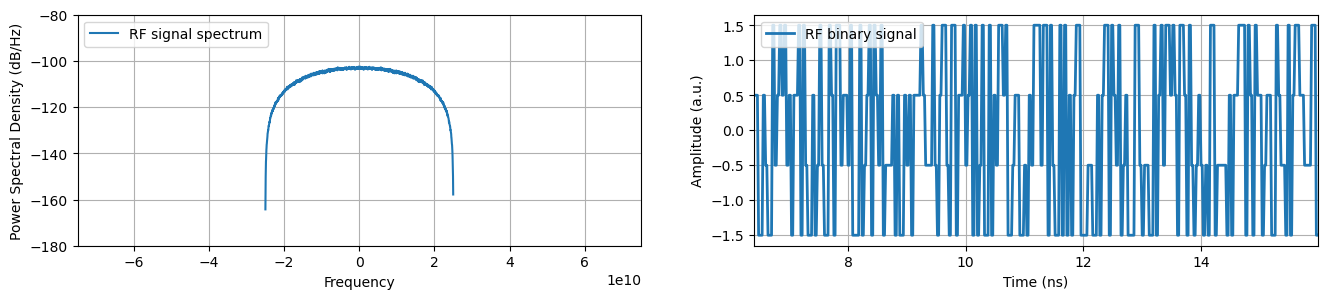

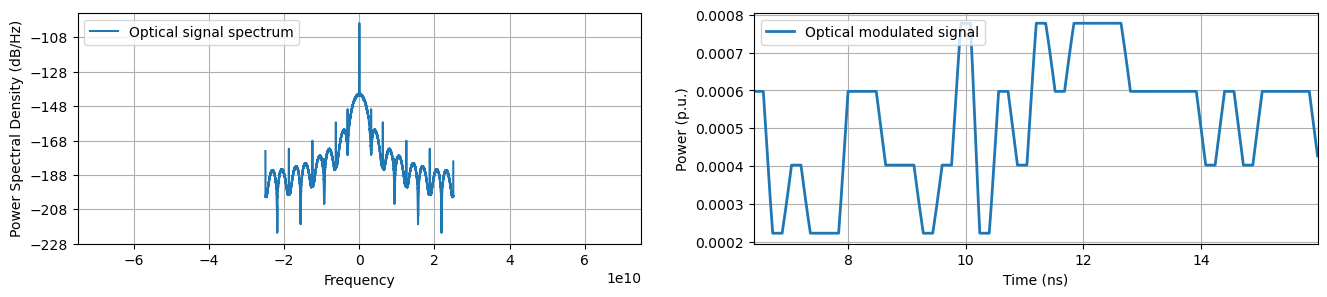

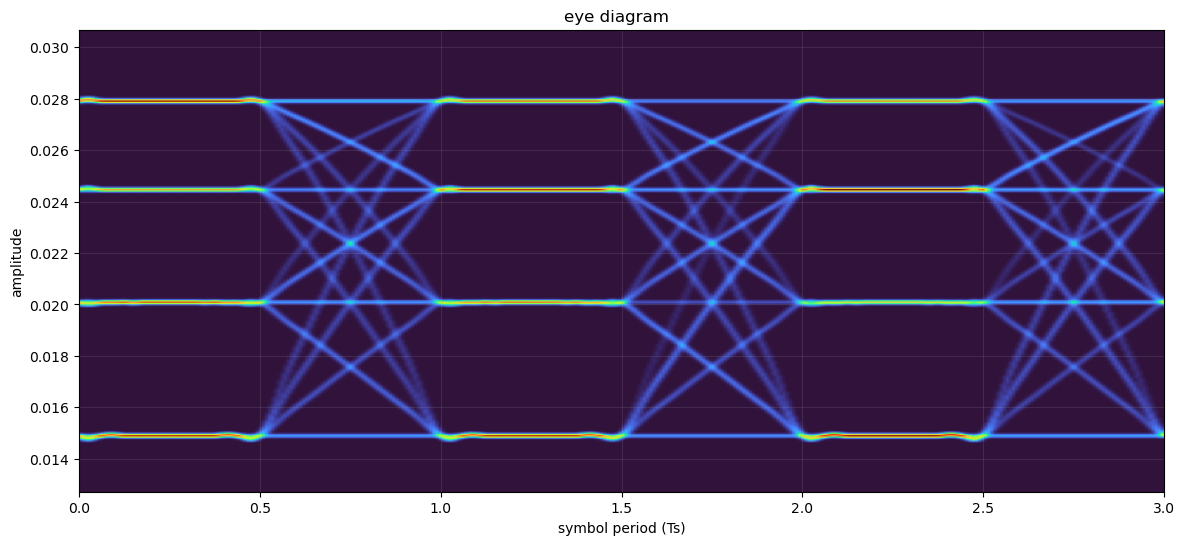

In [33]:
# Rate Sybol
Rs= 25e9

#Sample Per Symbol
SpS= 2

# Sample Rate
Fs= Rs*SpS
n_dac = 8

#Sample Time
Ts= 1/Fs

#Modulation Order
M= 4
Pi_dBm = 0         # laser optical power at the input of the MZM in dBm
Pi = dBm2W(Pi_dBm) # convert from dBm to W

#Parameters for Bits Generation
paramBits =  parameters()
paramBits.nBits = 500000
paramBits.mode= 'random'
paramBits.seed = 7
bits = bitSource(paramBits)

#Parameters for Modulation
symb_Tx= modulateGray(bits, M, 'pam')
symb_Tx_up = upsample(symb_Tx, SpS)

#Parameters for Pulse Shaping
paramPulse = parameters()
paramPulse.pulseType = 'rect'
paramPulse.SpS = SpS
pulse = pulseShape(paramPulse)

#Transmit Signal after Pulse Shaping
signal_Tx = firFilter(pulse, symb_Tx_up)

#DAC Parameters
paramDAC = parameters()
paramDAC.inFs = Fs            # Frequência de entrada (igual a Rs = 25e9)
paramDAC.outFs = n_dac*Fs        # Frequência de saída da simulação (Rs * SpS = 400e9)
paramDAC.nBits = 8         # Resolução nominal alta para emular DAC ideal
paramDAC.ENOB = 8           # Bits efetivos ideais (sem ruído térmico no DAC)
paramDAC.Vpp = 2*np.max(np.abs(signal_Tx))           # Tensão pico a pico elétrica normalizada
paramDAC.AIF = False         # Filtro Anti-Imagem desligado (evita filtro redundante)
signal_Tx_DAC = dac(signal_Tx, paramDAC)
#signal_Tx_DAC = signal_Tx

paramLaser = parameters()
paramLaser.P = Pi_dBm
paramLaser.lw = 0
paramLaser.RIN_var = 1e-14
paramLaser.Fs= paramDAC.outFs
paramLaser.Ns = len(signal_Tx_DAC)
laserTx = basicLaserModel(paramLaser)

paramMZM = parameters()
paramMZM.Vpi = 8
paramMZM.Vb= -paramMZM.Vpi/2

signal_optTx= mzm(laserTx, signal_Tx_DAC, paramMZM)


print('Average power of the modulated optical signal [mW]: %.3f mW'%(signalPower(signal_optTx)/1e-3))
print('Average power of the modulated optical signal [dBm]: %.3f dBm'%(10*np.log10(signalPower(signal_optTx)/1e-3)))


fig, axs = plt.subplots(1, 2, figsize=(16,3))
interval = np.arange(16*20,16*50)
t = interval*Ts/1e-9

# plot psd
axs[0].set_xlim(-3*Rs,3*Rs);
axs[0].set_ylim(-180,-80);
axs[0].psd(signal_Tx,Fs=Fs, NFFT = 2*1024, sides='twosided', label = 'RF signal spectrum')
axs[0].legend(loc='upper left');

axs[1].plot(t, signal_Tx[interval], label = 'RF binary signal', linewidth=2)
axs[1].set_ylabel('Amplitude (a.u.)')
axs[1].set_xlabel('Time (ns)')
axs[1].set_xlim(min(t),max(t))
axs[1].legend(loc='upper left')
axs[1].grid()

fig, axs = plt.subplots(1, 2, figsize=(16,3))
# plot psd
axs[0].set_xlim(-3*Rs,3*Rs);
axs[0].psd(signal_optTx, Fs=Fs, NFFT = 16*1024, sides='twosided', label = 'Optical signal spectrum')
axs[0].legend(loc='upper left');

axs[1].plot(t, np.abs(signal_optTx[interval])**2, label = 'Optical modulated signal', linewidth=2)
axs[1].set_ylabel('Power (p.u.)')
axs[1].set_xlabel('Time (ns)')
axs[1].set_xlim(min(t),max(t))
axs[1].legend(loc='upper left')
axs[1].grid()
plt.rcParams['figure.figsize'] = (14, 6)


eyediagram(np.real(signal_optTx), len(signal_optTx), n_dac*SpS ,ptype = 'fancy')

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def superGauss(f, n, B_3dB):
    '''
    Calculates the supergaussian filter frequency response for a given order n and 3dB bandwidth B_3dB.

    param:
        f (np.array): Frequency array (in Hz) for which to calculate the filter response.
        n (int): Order of the supergaussian filter.
        B_3dB (float): 3dB bandwidth of the filter (in Hz).
    
    return:
        H_sg (np.array): Frequency response of the supergaussian filter at the given frequencies.
    '''

    alpha = np.log(2)/2
    H_sg = np.exp(-alpha * (f / B_3dB)**(2*n))
    return H_sg

4000000


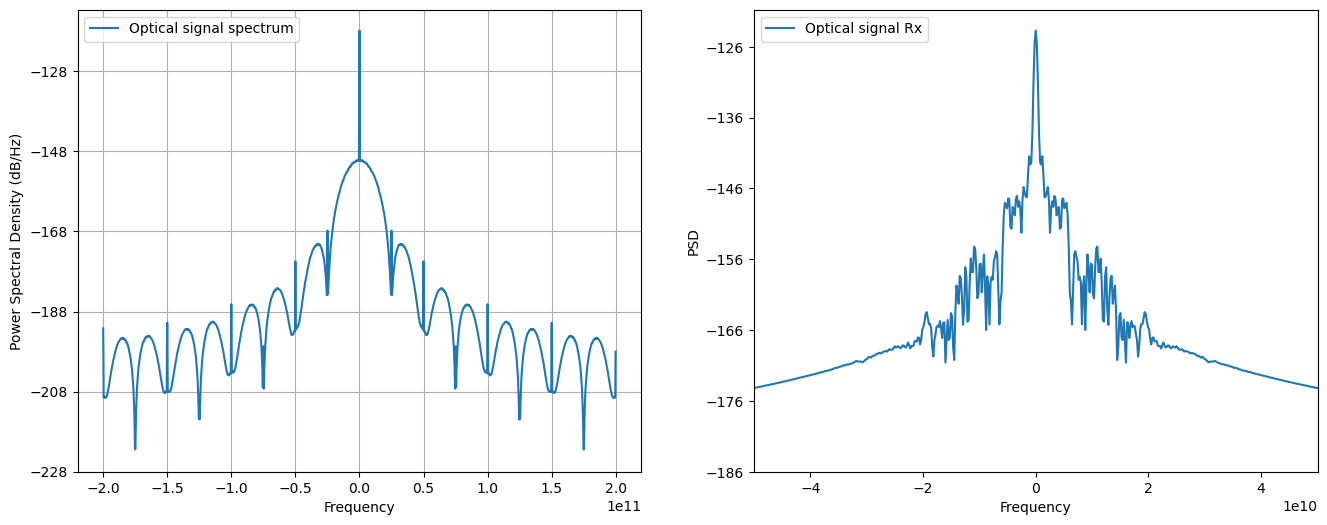

In [35]:
from scipy.fft import fft, ifft, fftfreq


# 1. Definir os parâmetros do canal baseados no artigo
# O artigo varia o B_3dB no eixo X dos gráficos (ex: de 0.1 a 1.5 * Rs)
# e testa a ordem do filtro como 1 e 3.
print(len(signal_optTx))
n_order = 1             # Ordem do supergaussiano (ex: 1 ou 3)
B_3dB = 0.4 * Rs        # Largura de banda em 40% da taxa de símbolos

# 2. Criar o vetor de frequências para o sinal de simulação
N_samples = 1024
sim_Fs = paramDAC.outFs # A taxa de amostragem do sinal modulado (400 GHz)

# Cria o vetor de frequências correspondente aos bins da FFT
f = fftfreq(N_samples, d=1/sim_Fs)

# 3. Gerar a resposta em frequência do canal
H_ch = superGauss(f, n_order, B_3dB)

# 4. Aplicar o filtro ao sinal no domínio da frequência
signal_optTx_fft = np.fft.fft(signal_optTx, n = 1024)
signal_optRx_fft = signal_optTx_fft * H_ch

# Retornar o sinal filtrado para o domínio do tempo
signal_optRx = ifft(signal_optRx_fft)

fig, axs = plt.subplots(1, 2, figsize=(16,6))
# plot psd
axs[0].psd(signal_optTx, Fs=paramDAC.outFs, NFFT = 2048, sides='twosided', label = 'Optical signal spectrum')
axs[0].legend(loc='upper left');

axs[1].psd(signal_optRx, Fs = paramDAC.outFs, NFFT = 2048, sides = 'twosided', label = "Optical signal Rx")
axs[1].set_ylabel('PSD')
axs[1].set_xlabel('Frequency')
axs[1].legend(loc='upper left')
axs[1].grid()
axs[1].set_xlim(-0.5e11, 0.5e11)
plt.rcParams['figure.figsize'] = (14, 6)



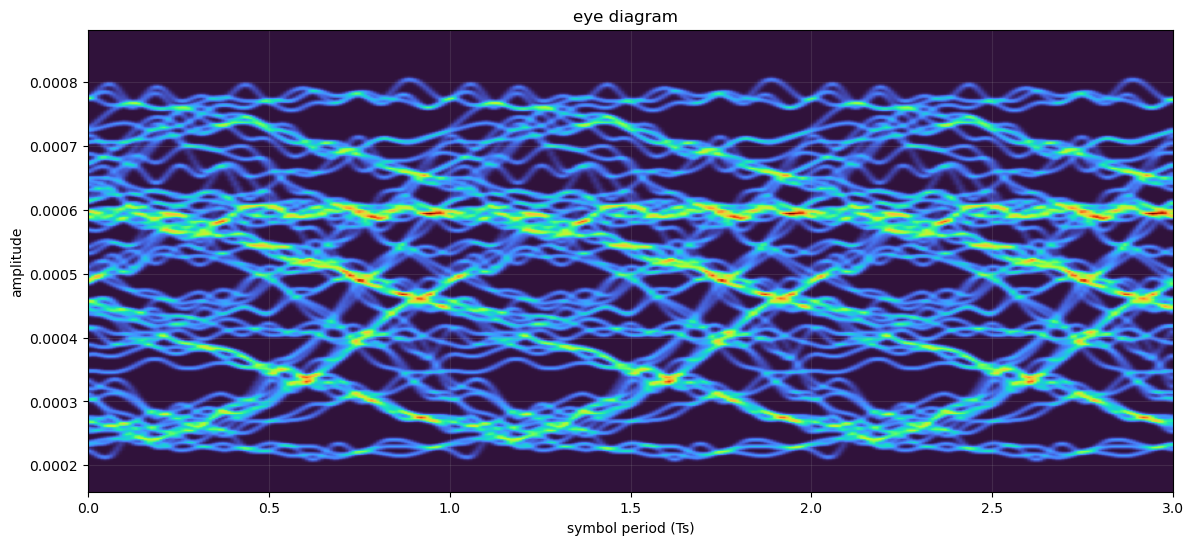

<function matplotlib.pyplot.show(close=None, block=None)>

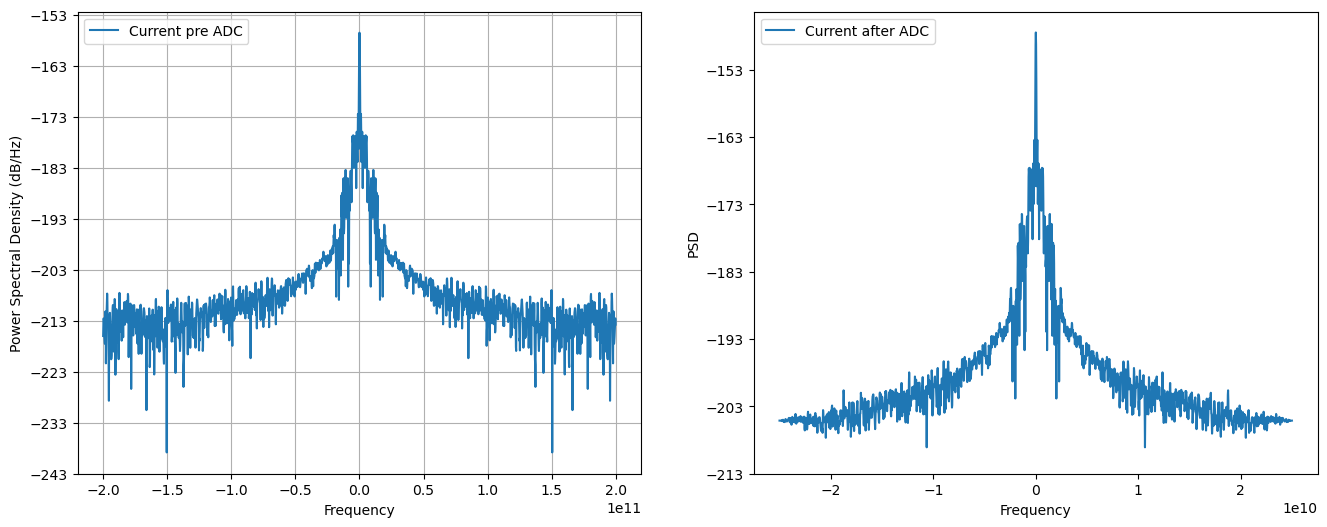

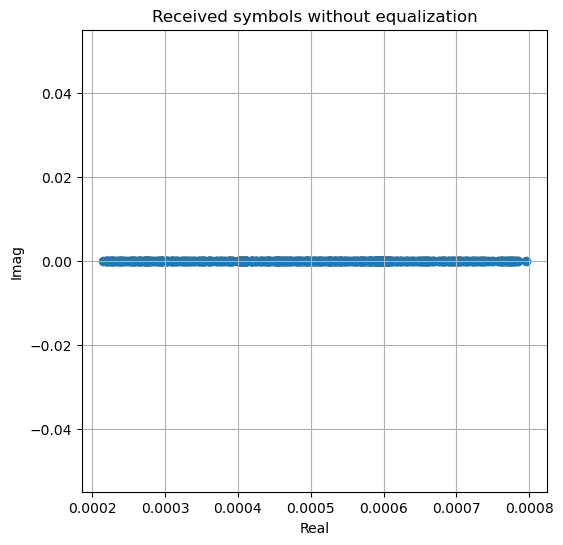

In [36]:
paramPD = parameters()
paramPD = parameters()
paramPD.R = 1.0                           # Responsividade de 1 A/W (Tabela I do artigo)
paramPD.Tc = 25                           # Não utilizado (o artigo fixa a PSD do ruído térmico)
paramPD.Id = 0                            # Corrente de escuro zero (omitida no modelo matemático)
paramPD.Ipd_sat = 5e-3                    # Irrelevante (saturação desligada)
paramPD.RL = 50                           # Irrelevante (ruído térmico fixado externamente)
paramPD.B = 30e9                          # Irrelevante (limitação de banda desligada aqui)
paramPD.Fs = paramDAC.outFs               # Frequência de amostragem global da simulação
paramPD.fType = 'rect'                    # Irrelevante
paramPD.PDN = 255                         # Irrelevante
paramPD.ideal = False                     # False para permitir a injeção de ruídos
paramPD.shotNoise = True                  # O modelo do artigo analisa o Shot Noise
paramPD.thermalNoise = True               # O modelo do artigo analisa o Ruído Térmico
paramPD.currentSaturation = False         # O modelo assume um receptor estritamente linear
paramPD.bandwidthLimitation = False       # IMPORTANTE: Desligado (veja explicação abaixo)
paramPD.seed = 7                          # Qualquer número inteiro

PD_signalRx= photodiode(signal_optRx, paramPD)

eyediagram(np.real(PD_signalRx), len(PD_signalRx), n_dac*SpS ,ptype = 'fancy', plotlabel = "" \
"")
#plt.psd(PD_signalRx, NFFT = 1024, Fs = paramDAC.outFs, sides = 'twosided')

paramAdc = parameters()
paramAdc.inFs = paramDAC.outFs
paramAdc.outFs = Fs
paramAdc.Nbits = paramDAC.nBits
paramAdc.ENOB = paramDAC.ENOB
paramAdc.Vmax = paramDAC.Vpp//2
paramAdc.Vmin = -paramDAC.Vpp//2
paramAdc.AAF = False

sigRx = adc(PD_signalRx, paramAdc)
sigRx = firFilter(pulse, PD_signalRx)
#sigRx = PD_signalRx

fig, axs = plt.subplots(1, 2, figsize=(16,6))
# plot psd
axs[0].psd(PD_signalRx, Fs=paramDAC.outFs, NFFT = 2048, sides='twosided', label = 'Current pre ADC')
axs[0].legend(loc='upper left');

axs[1].psd(sigRx, Fs = Fs, NFFT = 2048, sides = 'twosided', label = "Current after ADC")
axs[1].set_ylabel('PSD')
axs[1].set_xlabel('Frequency')
axs[1].legend(loc='upper left')
axs[1].grid()
plt.rcParams['figure.figsize'] = (14, 6)

paramDec = parameters()
paramDec.SpSin = SpS
paramDec.SpSout = 1

symbRx_vis = decimate(sigRx, paramDec)

plt.figure(figsize=(6,6))
plt.scatter(np.real(symbRx_vis), np.imag(symbRx_vis))

plt.title("Received symbols without equalization")
plt.xlabel("Real")
plt.ylabel("Imag")
plt.grid(True)
plt.show





ZeroDivisionError: division by zero

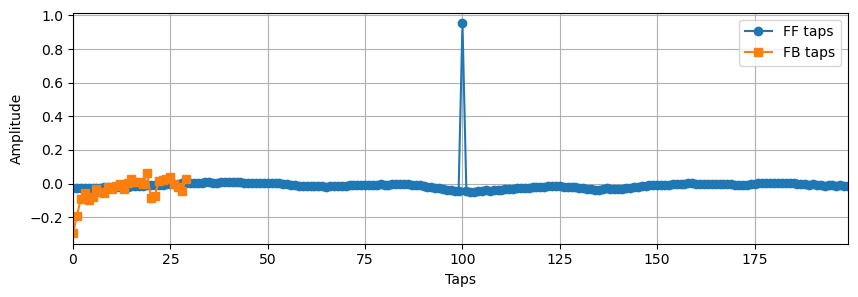

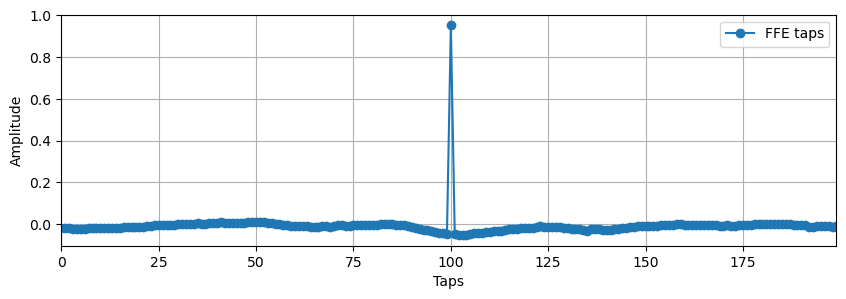

In [37]:
nTrain = 100000  # number of training symbols
plots = True  # enable/disable plots of equalizer taps and MSE convergence
trainingMode = "fulltime"

# Apply DFE equalization
paramDFE = parameters()
paramDFE.nTapsFF = 200
paramDFE.nTapsFB = 30
paramDFE.SpS = SpS
paramDFE.mu = 2e-3
paramDFE.nTrain = nTrain
paramDFE.M = M
paramDFE.trainingMode = trainingMode

outDFE, f, b, mseDFE = dfe(sigRx, symb_Tx, paramDFE)
#outDFE = pnorm(outDFE)

if plots:
    plt.figure(figsize=(10,3))
    plt.plot(f, 'o-', label='FF taps')
    plt.plot(b, 's-', label='FB taps')
    plt.xlim(0, max(len(f), len(b))-1)
    plt.xlabel('Taps')
    plt.ylabel('Amplitude')
    plt.grid()
    plt.legend()

# Apply FFE equalization
paramFFE = parameters()
paramFFE.nTaps = 200
paramFFE.mu = 2e-3
paramFFE.nTrain = nTrain
paramFFE.SpS = SpS
paramFFE.M = M
paramFFE.trainingMode = trainingMode

outFFE, h, mseFFE = ffe(sigRx, symb_Tx, paramFFE)
#outFFE = pnorm(outFFE)

if plots:
    plt.figure(figsize=(10,3))
    plt.plot(h, 'o-', label='FFE taps')
    plt.legend()
    plt.xlim(0, len(h)-1)
    plt.xlabel('Taps')
    plt.ylabel('Amplitude')
    plt.grid()

discard = nTrain

# with FFE equalization
ber_ffe, ser_ffe, snr_ffe = fastBERcalc(outFFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')

# with DFE equalization
ber_dfe, ser_dfe, snr_dfe = fastBERcalc(outDFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')

print('Performance results:')
print('------------------------------------')
print('Method      |  BER       |  SNR (dB)')
print('------------------------------------')
print(f'FFE         |  {ber_ffe[0]:.2e}  |  {snr_ffe[0]:.2f} ')
print(f'DFE         |  {ber_dfe[0]:.2e}  |  {snr_dfe[0]:.2f} ') 